<a href="https://colab.research.google.com/github/seongwoojang1123/Effusion-OSA-TMD/blob/main/2_data_initial_analyze_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
import matplotlib.patheffects as pe
from math import ceil

file_path = '/content/drive/MyDrive/Effusion OSA TMD/20250831_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

결과 변수 Distribution

Effusion
1    0.696833
0    0.303167
Name: proportion, dtype: float64


/tmp/ipython-input-1422855563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effusion', palette="Set2")


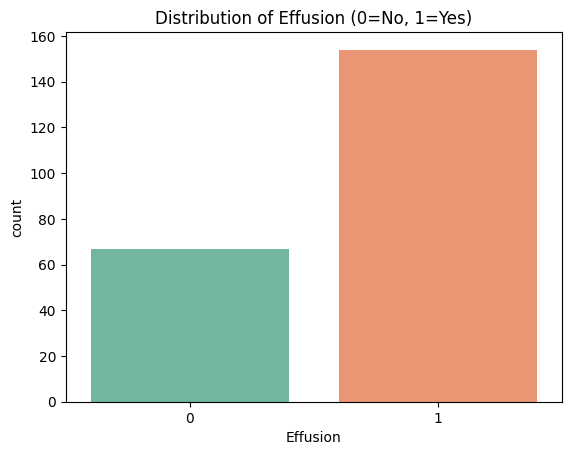

In [ ]:
print(df['Effusion'].value_counts(normalize=True))

sns.countplot(data=df, x='Effusion', palette="Set2")
plt.title("Distribution of Effusion (0=No, 1=Yes)")
plt.show()

/tmp/ipython-input-4268879368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effusion grade', palette="Set3")


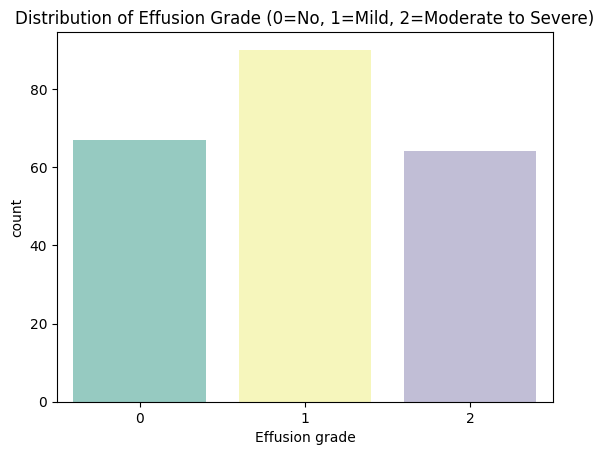

In [ ]:
sns.countplot(data=df, x='Effusion grade', palette="Set3")
plt.title("Distribution of Effusion Grade (0=No, 1=Mild, 2=Moderate to Severe)")
plt.show()

주요 연속형 변수 Distribution & Effusion 그룹별 Boxplot

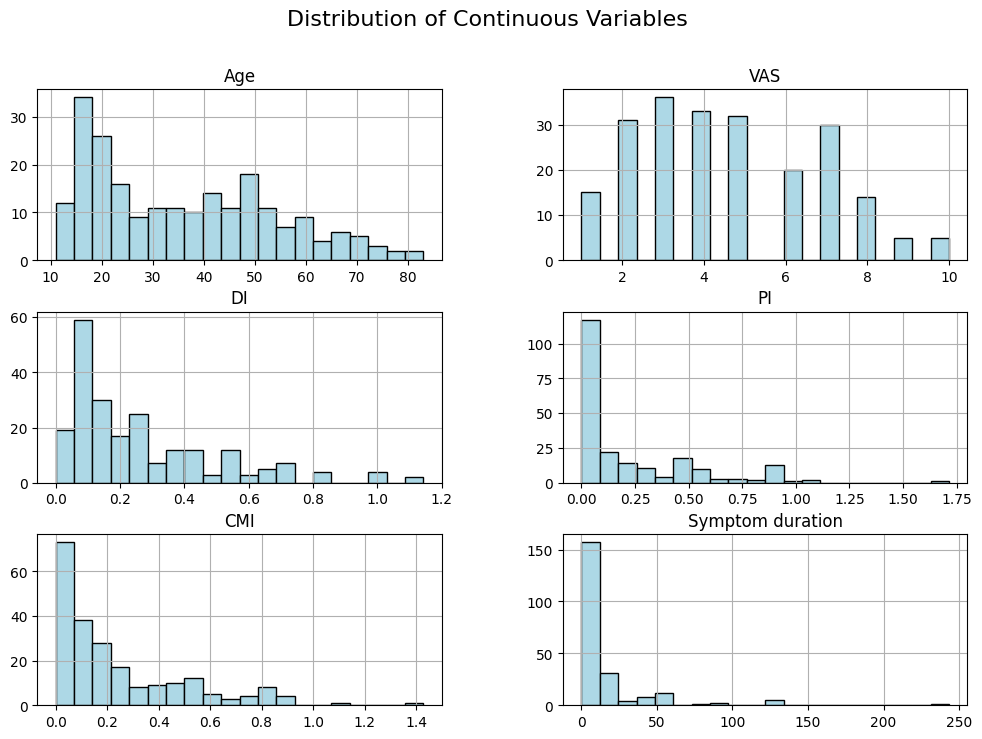

In [ ]:
cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

df[cont_vars].hist(bins=20, figsize=(12,8), color="lightblue", edgecolor="black")
plt.suptitle("Distribution of Continuous Variables", fontsize=16)
plt.show()

/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

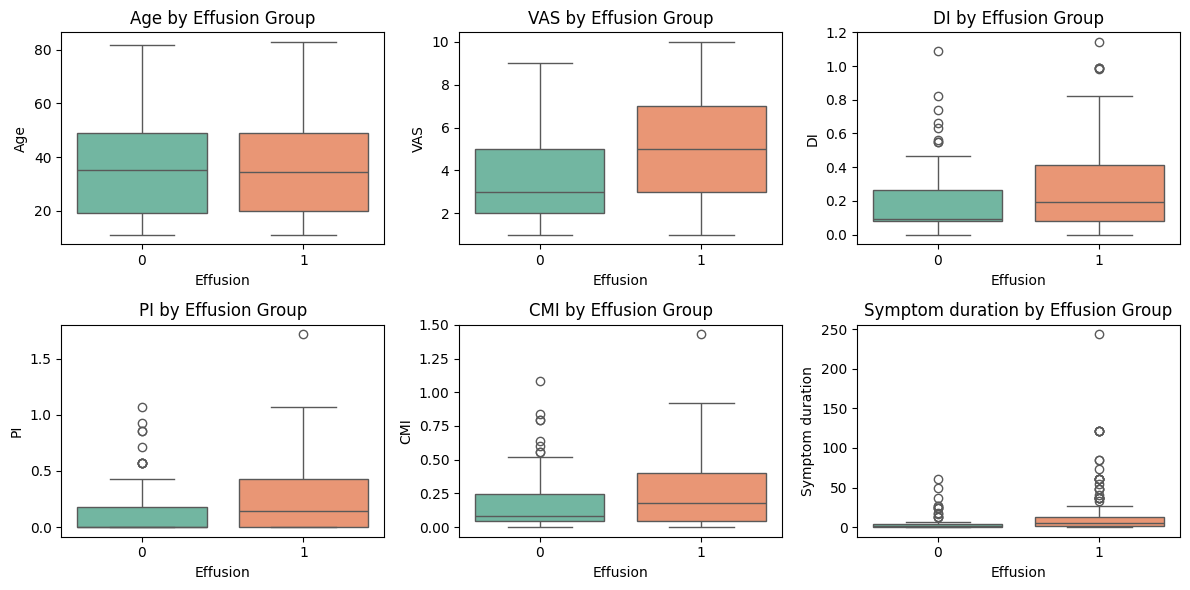

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(cont_vars, 1):
    plt.subplot(2,3,i)
    sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
    plt.title(f"{col} by Effusion Group")
plt.tight_layout()
plt.show()

Effusion vs 범주형 변수

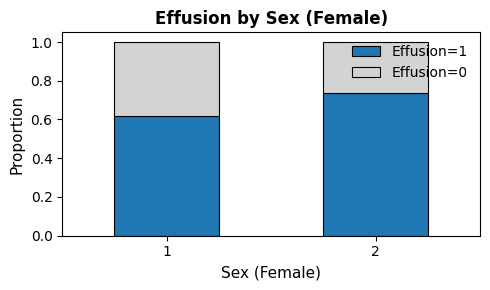

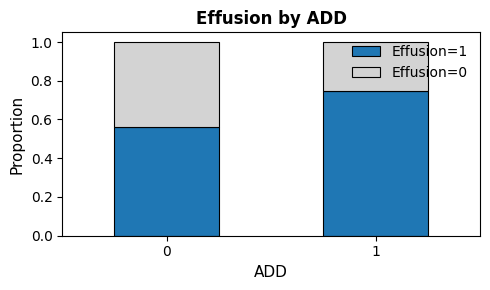

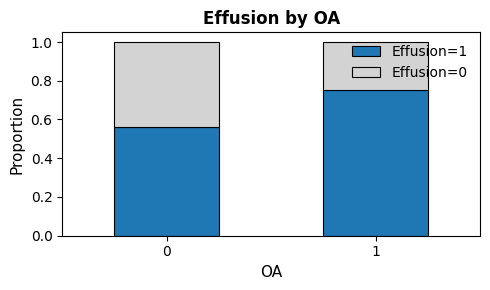

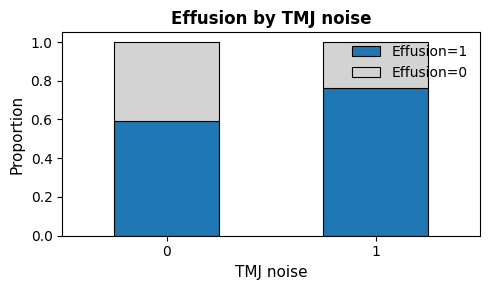

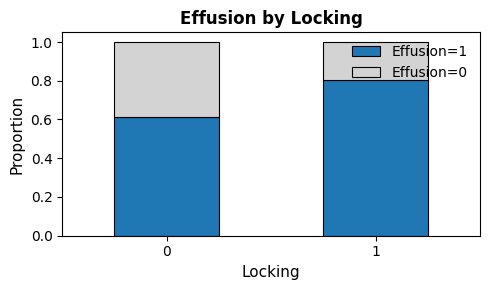

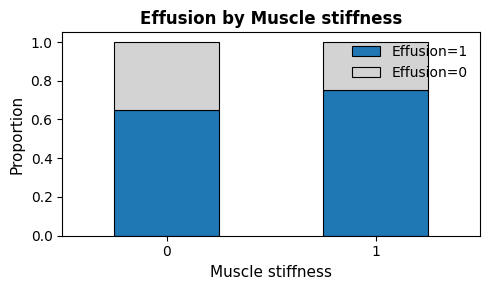

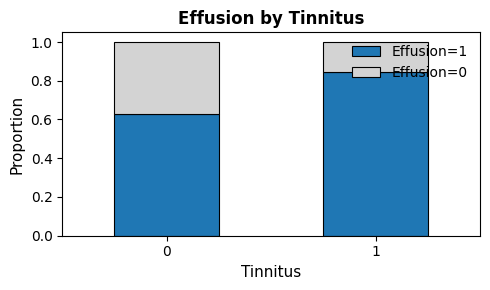

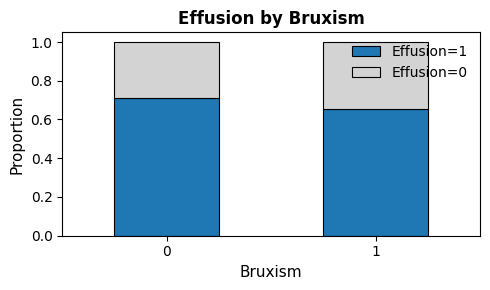

In [ ]:

cat_vars = ['Sex (Female)', 'ADD','OA','TMJ noise','Locking',
            'Muscle stiffness','Tinnitus','Bruxism']

for col in cat_vars:
    ct = pd.crosstab(df[col], df['Effusion'], normalize='index')

    # 컬럼 순서를 Effusion=1 먼저 오도록 정렬 (아래쪽에 배치됨)
    ct = ct[[1,0]]

    # plot
    ax = ct.plot(kind='bar', stacked=True, figsize=(5,3),
                 color=["#1f77b4", "lightgray"],  # 1=컬러, 0=회색
                 edgecolor="black", linewidth=0.8)

    plt.title(f"Effusion by {col}", fontsize=12, weight="bold")
    plt.ylabel("Proportion", fontsize=11)
    plt.xlabel(col, fontsize=11)
    plt.xticks(rotation=0)

    # legend 정리
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, ["Effusion=1", "Effusion=0"],
               loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()

Effusion에 대한 변수 비교

In [2]:

# -----------------------------
# 변수 정의
# -----------------------------
cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

cat_vars = [
    'Sex (Female)','ADD','OA',
    'TMJ noise','Locking',
    'Muscle stiffness','Tinnitus','Bruxism'
]

# -----------------------------
# 그룹 분리
# -----------------------------
group0 = df[df['Effusion']==0]
group1 = df[df['Effusion']==1]

rows = []

# -----------------------------
# p-value 포맷 함수 (추가 개선)
# -----------------------------
def format_p(p):
    if p < 0.001:
        return "<0.001***"
    elif p < 0.01:
        return f"{p:.3f}**"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"

# =============================
# 1) 연속형 변수
# =============================
for col in cont_vars:

    mean0, sd0 = group0[col].mean(), group0[col].std()
    mean1, sd1 = group1[col].mean(), group1[col].std()

    stat, p = stats.ttest_ind(
        group0[col].dropna(),
        group1[col].dropna(),
        equal_var=False  # 🔥 더 안전한 Welch t-test
    )

    rows.append([
        col,
        f"{mean0:.2f} ± {sd0:.2f}",
        f"{mean1:.2f} ± {sd1:.2f}",
        format_p(p)
    ])

# =============================
# 2) 범주형 변수 (핵심 수정!)
# =============================
for col in cat_vars:

    # 🔥 Yes(=1) 기준 count
    count0 = (group0[col] == 1).sum()
    count1 = (group1[col] == 1).sum()

    total0 = len(group0)
    total1 = len(group1)

    val0 = f"{count0} ({count0/total0*100:.1f}%)"
    val1 = f"{count1} ({count1/total1*100:.1f}%)"

    # chi-square
    ctab = pd.crosstab(df[col], df['Effusion'])
    chi2, p, dof, exp = stats.chi2_contingency(ctab)

    rows.append([col, val0, val1, format_p(p)])

# -----------------------------
# Table 생성
# -----------------------------
table1 = pd.DataFrame(
    rows,
    columns=["Variable","Effusion=0","Effusion=1","P-value"]
)

print(table1)

            Variable     Effusion=0     Effusion=1    P-value
0                Age  35.70 ± 18.42  36.17 ± 17.82      0.861
1                VAS    3.45 ± 2.09    5.08 ± 2.16  <0.001***
2                 DI    0.21 ± 0.23    0.29 ± 0.24     0.014*
3                 PI    0.16 ± 0.27    0.24 ± 0.30     0.048*
4                CMI    0.18 ± 0.24    0.27 ± 0.26     0.025*
5   Symptom duration   6.34 ± 11.90  17.25 ± 32.34  <0.001***
6       Sex (Female)     28 (41.8%)     45 (29.2%)      0.095
7                ADD     41 (61.2%)    121 (78.6%)     0.012*
8                 OA     39 (58.2%)    118 (76.6%)    0.009**
9          TMJ noise     33 (49.3%)    105 (68.2%)     0.012*
10           Locking     19 (28.4%)     78 (50.6%)    0.003**
11  Muscle stiffness     26 (38.8%)     79 (51.3%)      0.118
12          Tinnitus     11 (16.4%)     60 (39.0%)    0.002**
13           Bruxism     18 (26.9%)     34 (22.1%)      0.549


Effusion Grade에 대한 변수 비교

In [3]:
# -----------------------------
# 변수 정의
# -----------------------------
cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

cat_vars = [
    'Sex (Female)','ADD','OA',
    'TMJ noise','Locking',
    'Muscle stiffness','Tinnitus','Bruxism'
]

groups = sorted(df['Effusion grade'].unique())

rows = []

# =============================
# 1) 연속형 변수 (ANOVA)
# =============================
for col in cont_vars:

    values = []

    for g in groups:
        sub = df[df['Effusion grade']==g][col].dropna()
        values.append(f"{sub.mean():.2f} ± {sub.std():.2f}")

    arrays = [df[df['Effusion grade']==g][col].dropna() for g in groups]
    stat, p = stats.f_oneway(*arrays)

    rows.append([col] + values + [format_p(p)])

# =============================
# 2) 범주형 변수 (핵심 수정!)
# =============================
for col in cat_vars:

    values = []

    for g in groups:

        sub = df[df['Effusion grade']==g]

        # 🔥 Yes(=1)만 카운트
        count = (sub[col] == 1).sum()
        total = len(sub)

        values.append(f"{count} ({count/total*100:.1f}%)")

    # chi-square
    ctab = pd.crosstab(df[col], df['Effusion grade'])
    chi2, p, dof, exp = stats.chi2_contingency(ctab)

    rows.append([col] + values + [format_p(p)])

# -----------------------------
# Table 생성
# -----------------------------
table2 = pd.DataFrame(
    rows,
    columns=["Variable"] + [f"Effusion={g}" for g in groups] + ["P-value"]
)

print(table2)

            Variable     Effusion=0     Effusion=1     Effusion=2    P-value
0                Age  35.70 ± 18.42  36.02 ± 17.68  36.38 ± 18.15      0.977
1                VAS    3.45 ± 2.09    4.72 ± 2.22    5.59 ± 1.99  <0.001***
2                 DI    0.21 ± 0.23    0.25 ± 0.20    0.35 ± 0.28    0.003**
3                 PI    0.16 ± 0.27    0.19 ± 0.23    0.31 ± 0.37    0.005**
4                CMI    0.18 ± 0.24    0.22 ± 0.21    0.33 ± 0.32    0.003**
5   Symptom duration   6.34 ± 11.90  21.71 ± 38.18  10.96 ± 20.27    0.002**
6       Sex (Female)     28 (41.8%)     32 (35.6%)     13 (20.3%)     0.026*
7                ADD     41 (61.2%)     72 (80.0%)     49 (76.6%)     0.024*
8                 OA     39 (58.2%)     67 (74.4%)     51 (79.7%)     0.017*
9          TMJ noise     33 (49.3%)     61 (67.8%)     44 (68.8%)     0.028*
10           Locking     19 (28.4%)     44 (48.9%)     34 (53.1%)    0.008**
11  Muscle stiffness     26 (38.8%)     43 (47.8%)     36 (56.2%)      0.135

Stripplot, Boxplot

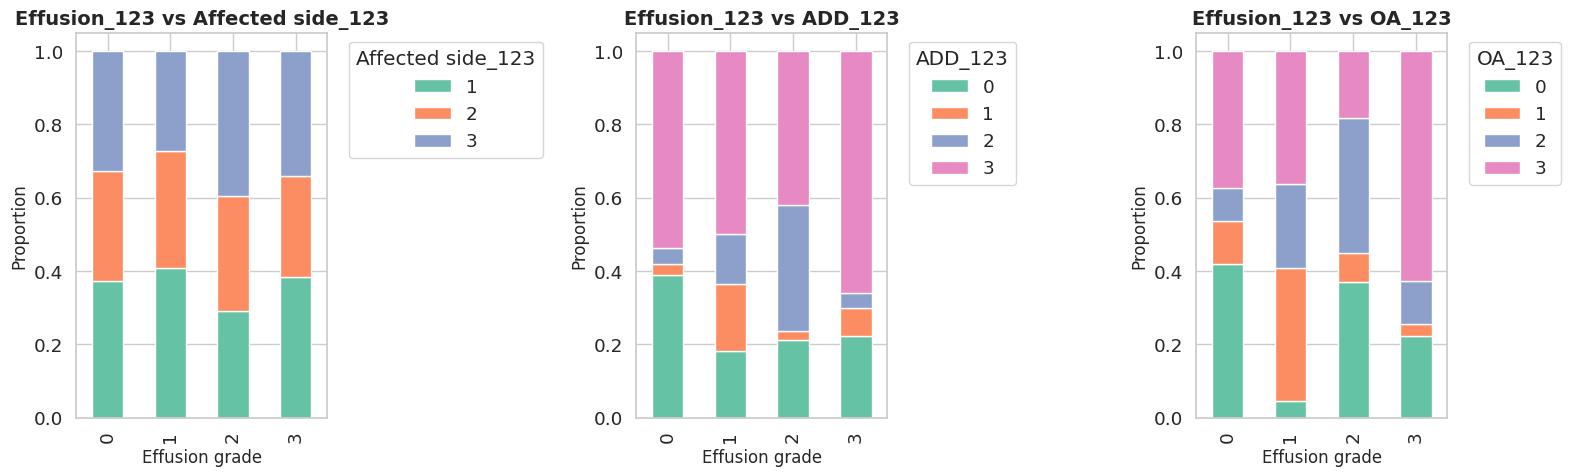

In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

x_var = 'Effusion_123'
y_vars = ['Affected side_123', 'ADD_123', 'OA_123']

plt.figure(figsize=(16,5))

for i, y in enumerate(y_vars, 1):
    plt.subplot(1,3,i)

    # 교차표 (비율)
    ctab = pd.crosstab(df[x_var], df[y], normalize='index')
    ctab.plot(kind='bar', stacked=True, ax=plt.gca(),
              color=sns.color_palette("Set2", n_colors=ctab.shape[1]))

    plt.title(f"{x_var} vs {y}", fontsize=14, weight="bold")
    plt.xlabel("Effusion grade", fontsize=12)
    plt.ylabel("Proportion", fontsize=12)
    plt.legend(title=y, bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


Heatmap

Effusion_123 vs Affected side_123: Chi2=1.66, p=0.948
Effusion_123 vs ADD_123: Chi2=42.19, p=0.000
Effusion_123 vs OA_123: Chi2=58.44, p=0.000


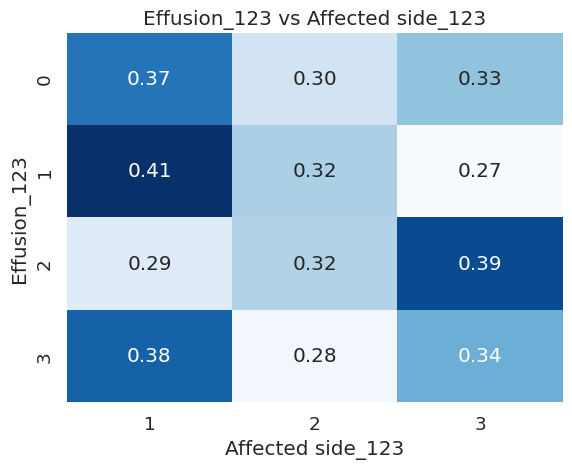

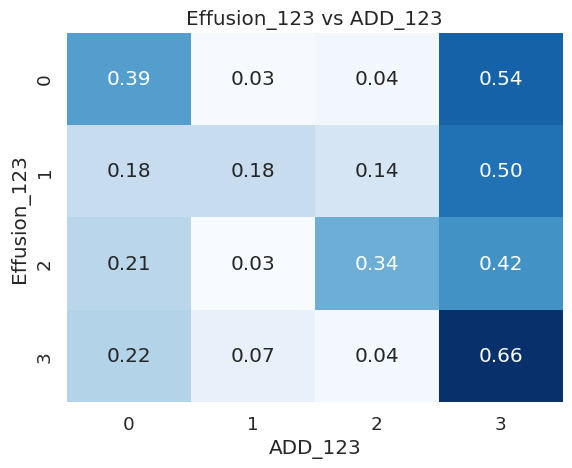

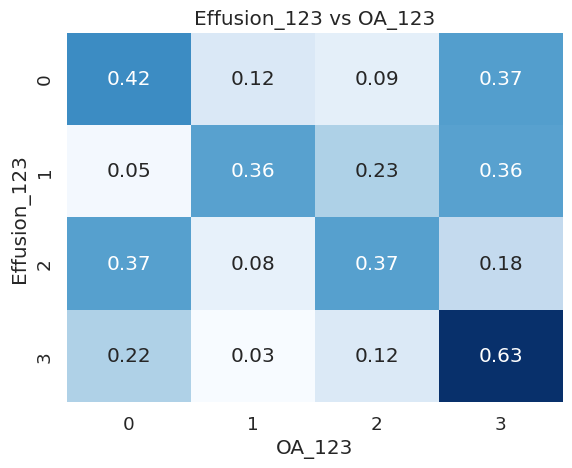

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

for y in y_vars:
    ctab = pd.crosstab(df[x_var], df[y])
    chi2, p, dof, exp = chi2_contingency(ctab)
    print(f"{x_var} vs {y}: Chi2={chi2:.2f}, p={p:.3f}")

for y in y_vars:
    ctab = pd.crosstab(df[x_var], df[y], normalize='index')
    sns.heatmap(ctab, annot=True, cmap="Blues", cbar=False, fmt=".2f")
    plt.title(f"{x_var} vs {y}")
    plt.show()


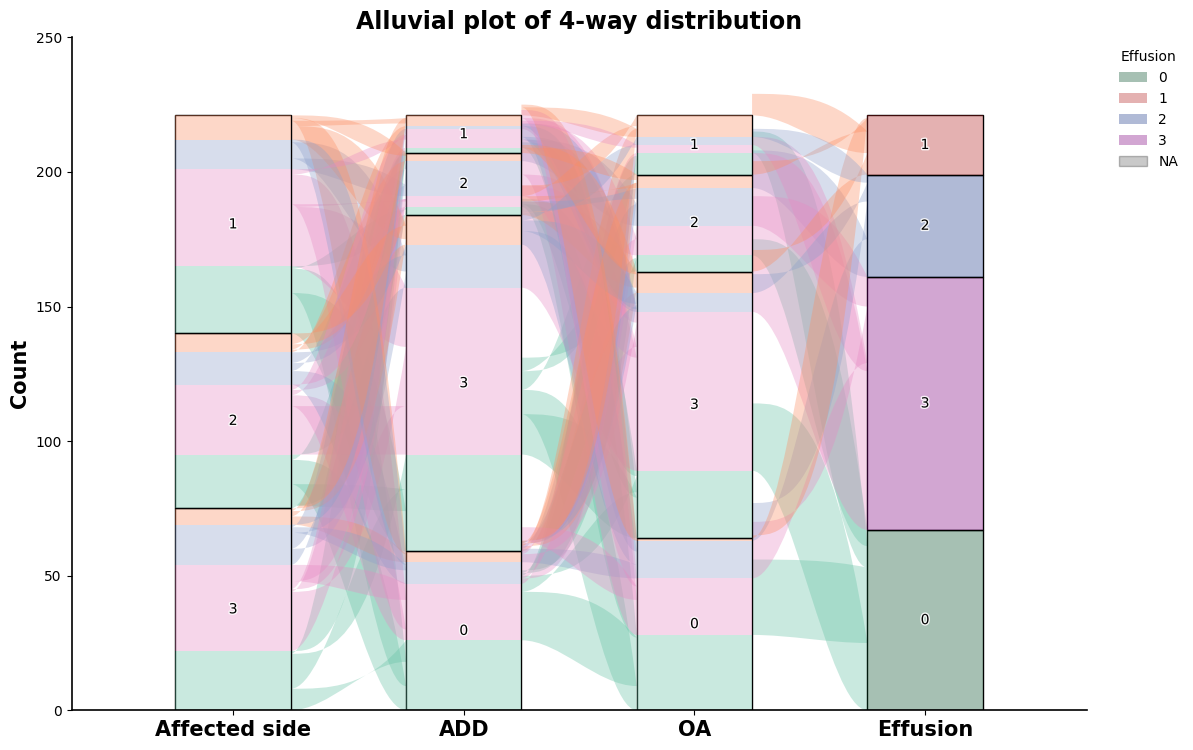

In [2]:
# ==== Alluvial: tuned size, darker 4th bar, black labels/lines ====

cols = ["Affected side_123", "ADD_123", "OA_123", "Effusion_123"]

# 기본 팔레트(리본/기본 바 색)
effusion_palette = {"0":"#66c2a5","1":"#fc8d62","2":"#8da0cb","3":"#e78ac3","NA":"#ffffff"}
effusion_edge = "#404040"
seg_alpha = 0.35  # 리본/바 색띠 투명도

# --- 헬퍼: 색 어둡게 ---
def darken(hexcolor, factor=0.7):
    # factor < 1 이면 어두워짐 (0.8 = 20% darker)
    if hexcolor.startswith("#") and len(hexcolor) == 7:
        r = int(hexcolor[1:3], 16)
        g = int(hexcolor[3:5], 16)
        b = int(hexcolor[5:7], 16)
        r = int(max(0, min(255, r * factor)))
        g = int(max(0, min(255, g * factor)))
        b = int(max(0, min(255, b * factor)))
        return "#{:02x}{:02x}{:02x}".format(r, g, b)
    return hexcolor

# 4번째 바(Effusion_123)만 더 진한 팔레트
effusion_palette_dark = {
    "0": "#004d26",   # 진한 초록 (Dark Green)
    "1": "#b22222",   # 진한 빨강/주황 (Firebrick)
    "2": "#1e3a8a",   # 진한 파랑 (Navy/Indigo)
    "3": "#800080",   # 진한 보라 (Purple)
    "NA": "#666666"   # NA는 진한 회색
}

# ---- 데이터 전처리 ----
df_alluv = df.copy()
for c in cols:
    df_alluv[c] = df_alluv[c].where(df_alluv[c].notna(), "NA").astype(str)

# ---- 쌓임 순서 ----
order_map = {
    "Affected side_123": ["3","2","1","0","NA"],  # 아래→위: 3,2,1
    "ADD_123":           ["0","3","2","1","NA"],  # 아래→위: 0,3,2,1
    "OA_123":            ["0","3","2","1","NA"],
    "Effusion_123":      ["0","3","2","1","NA"]
}
eff_order = ["0","3","2","1","NA"]

def ordered_levels(c, counts_dict):
    base = order_map.get(c, ["0","1","2","3","NA"])
    ordered = [lv for lv in base if lv in counts_dict]
    rest = [lv for lv in counts_dict if lv not in base]
    return ordered + sorted(rest)

# ---- 카운트/블록 범위 ----
col_counts = {c: df_alluv[c].value_counts(dropna=False).to_dict() for c in cols}
max_total = max(sum(col_counts[c].values()) for c in cols)
block_ranges = {}
for c in cols:
    y = 0
    for lv in ordered_levels(c, col_counts[c]):
        h = col_counts[c][lv]
        block_ranges[(c, lv)] = (y, y + h)
        y += h

# ---- 바 내부 색띠 높이/시작위치 ----
segment_heights, segment_start = {}, {}
for c in cols:
    for lv in ordered_levels(c, col_counts[c]):
        sub = df_alluv[df_alluv[c]==lv][cols[-1]].value_counts(dropna=False).to_dict()
        sh = {ec: int(sub.get(ec, 0)) for ec in eff_order}
        segment_heights[(c, lv)] = sh
        y0, _ = block_ranges[(c, lv)]
        ycur, off = y0, {}
        for ec in eff_order:
            off[ec] = ycur
            ycur += sh[ec]
        segment_start[(c, lv)] = off

used_offsets = {(c, lv, ec): 0 for c in cols for lv in col_counts[c] for ec in eff_order}

# ---- 단계 간 흐름(리본) ----
flows = {}
for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    keys = [left, right] + ([] if right==cols[-1] else [cols[-1]])
    keys = list(dict.fromkeys(keys))
    tmp = df_alluv.groupby(keys, dropna=False, sort=False).size().reset_index(name="count")
    flows[(left, right)] = tmp

def ribbon(ax, x0, x1, y0a, y0b, y1a, y1b, color, alpha):
    verts = [(x0,y0a),(x0+0.33*(x1-x0),y0a),(x0+0.66*(x1-x0),y1a),(x1,y1a),
             (x1,y1b),(x0+0.66*(x1-x0),y0b),(x0+0.33*(x1-x0),y0b),(x0,y0b),(x0,y0a)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,
             Path.LINETO,Path.CURVE4,Path.CURVE4,Path.CURVE4,Path.CLOSEPOLY]
    ax.add_patch(PathPatch(Path(verts,codes), facecolor=color, edgecolor="none", alpha=alpha, zorder=1))

# ---- 그리기 ----
fig, ax = plt.subplots(figsize=(12, 7.6))   # <<< (1) 사이즈 조정
x_positions = np.arange(len(cols))

# (a) 바 아웃라인 + 내부 색띠
for i, c in enumerate(cols):
    # 이 바에 사용할 팔레트 (4번째 바만 더 진하게)
    bar_palette = effusion_palette_dark if c == "Effusion_123" else effusion_palette
    for lv in ordered_levels(c, col_counts[c]):
        y0, y1 = block_ranges[(c, lv)]
        # 외곽선(검정색)  <<< (3)
        ax.add_patch(Rectangle((i-0.25, y0), 0.5, (y1-y0),
                               facecolor='none', edgecolor="black", linewidth=1, zorder=2))
        # 내부 색띠
        for ec in eff_order:
            h = segment_heights[(c, lv)][ec]
            if h <= 0:
                continue
            ax.add_patch(Rectangle((i-0.25, segment_start[(c, lv)][ec]), 0.5, h,
                                   facecolor=bar_palette.get(ec, "#cccccc"),
                                   edgecolor="none", alpha=seg_alpha, zorder=2))
        # 중앙 숫자(검정)  <<< (3)
        if (y1-y0) >= 12:
            ax.text(i, (y0+y1)/2, lv, ha="center", va="center", fontsize=10,
                    color="black",
                    path_effects=[pe.withStroke(linewidth=2, foreground="white", alpha=0.85)],
                    zorder=3)

# (b) 리본 (색은 기본 팔레트 유지)
for s in range(len(cols)-1):
    left, right = cols[s], cols[s+1]
    x0, x1 = x_positions[s] + 0.25, x_positions[s+1] - 0.25
    tmp = flows[(left, right)]
    for _, row in tmp.iterrows():
        lv_l, lv_r = str(row[left]), str(row[right])
        eff_cat = str(row[cols[-1]] if cols[-1] in row.index else row[right])
        cnt = int(row["count"])
        y0a = segment_start[(left, lv_l)][eff_cat]  + used_offsets[(left, lv_l, eff_cat)]
        y0b = y0a + cnt
        y1a = segment_start[(right, lv_r)][eff_cat] + used_offsets[(right, lv_r, eff_cat)]
        y1b = y1a + cnt
        ribbon(ax, x0, x1, y0a, y0b, y1a, y1b,
               color=effusion_palette.get(eff_cat, "#cccccc"), alpha=seg_alpha)
        used_offsets[(left, lv_l, eff_cat)]  += cnt
        used_offsets[(right, lv_r, eff_cat)] += cnt

# (c) 축/격자/범례  <<< (3) 라인 모두 검정
y_step = 50
ymax = max(200, y_step * ceil(max_total / y_step))
ax.set_ylim(0, ymax); ax.set_xlim(-0.7, len(cols)-0.3)
ax.set_axisbelow(True)
ax.set_yticks(np.arange(0, ymax+1, y_step))
ax.grid(which="major", axis="y", linestyle="-", linewidth=0.8, color="white")    # y-그리드 검정
for x in x_positions:
    ax.axvline(x=x, ymin=0, ymax=1, color="white", linewidth=0.8, zorder=0)     # 세로선 검정
for spine in ["left","bottom"]:
    ax.spines[spine].set_visible(True); ax.spines[spine].set_linewidth(1.2); ax.spines[spine].set_color("black")
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

ax.set_xticks(x_positions)
ax.set_xticklabels([c.replace("_123", "") for c in cols],
                   fontsize=15, fontweight="bold", color="black")
ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
ax.set_title("Alluvial plot of 4-way distribution",
             fontsize=17, fontweight="bold", color="black")

#ax.set_xticks(x_positions); ax.set_xticklabels(cols, fontsize=15, fontweight="bold", color="black")
#ax.set_ylabel("Count", fontsize=15, fontweight="bold", color="black")
#ax.set_title("Alluvial plot of 4-way distribution", fontsize=17, fontweight="bold", color="black")

# 범례(바깥) – 기본 팔레트, 동일 투명도
legend_keys = ["0","1","2","3","NA"]
legend_handles = [Rectangle((0,0),1,1,
                            facecolor=(effusion_palette_dark[k] if c=="Effusion_123" else effusion_palette[k]),
                            edgecolor=effusion_edge if k=="NA" else "none",
                            alpha=seg_alpha) for k in legend_keys]
ax.legend(legend_handles, legend_keys, title="Effusion",
          loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=False)
fig.subplots_adjust(right=0.82)

plt.tight_layout()
plt.show()
